In [23]:
import pandas as pd

movies = pd.read_csv("../data/raw/ml-latest-small/movies.csv")
ratings = pd.read_csv("../data/raw/ml-latest-small/ratings.csv")

print("Movies Dataset")
print(movies.head())

print("\nRatings Dataset")
print(ratings.head())

Movies Dataset
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Ratings Dataset
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [24]:
print("Movies Shape:", movies.shape)
print("Ratings Shape:", ratings.shape)

Movies Shape: (9742, 3)
Ratings Shape: (100836, 4)


In [25]:
print(movies.isnull().sum())
print(ratings.isnull().sum())

movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [26]:
print(movies.info())
print(ratings.info())

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


In [27]:
print("Unique Users:", ratings['userId'].nunique())
print("Unique Movies:", ratings['movieId'].nunique())

Unique Users: 610
Unique Movies: 9724


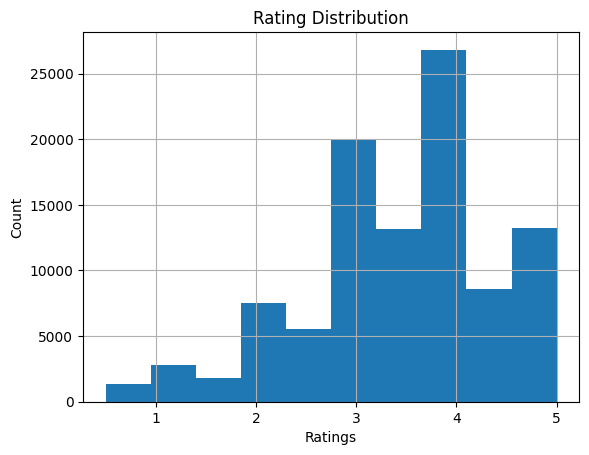

In [28]:
import matplotlib.pyplot as plt

ratings['rating'].hist()
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

In [29]:
movie_ratings = ratings.merge(movies, on='movieId')

movie_ratings.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [30]:
movie_stats = movie_ratings.groupby('title').agg({
    'rating': ['mean', 'count']
})

movie_stats.head()

rating      
                                          mean count
title                                               
'71 (2014)                                 4.0     1
'Hellboy': The Seeds of Creation (2004)    4.0     1
'Round Midnight (1986)                     3.5     2
'Salem's Lot (2004)                        5.0     1
'Til There Was You (1997)                  4.0     2

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [32]:
movies['genres'] = movies['genres'].fillna('')

In [33]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

print(tfidf_matrix.shape)

(9742, 23)


In [34]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(cosine_sim.shape)

(9742, 9742)


In [35]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

indices.head()

title
Toy Story (1995)                      0
Jumanji (1995)                        1
Grumpier Old Men (1995)               2
Waiting to Exhale (1995)              3
Father of the Bride Part II (1995)    4
dtype: int64

In [36]:
def recommend_movies(title, cosine_sim=cosine_sim):
    
    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:11]

    movie_indices = [i[0] for i in sim_scores]

    return movies[['title', 'genres']].iloc[movie_indices]

In [37]:
recommend_movies('Toy Story (1995)')

,title,genres
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6194,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
6486,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
6948,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy
7760,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy
8219,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy


In [38]:
recommend_movies('Jumanji (1995)')

,title,genres
53,"Indian in the Cupboard, The (1995)",Adventure|Children|Fantasy
109,"NeverEnding Story III, The (1994)",Adventure|Children|Fantasy
767,Escape to Witch Mountain (1975),Adventure|Children|Fantasy
1514,Darby O'Gill and the Little People (1959),Adventure|Children|Fantasy
1556,Return to Oz (1985),Adventure|Children|Fantasy
1617,"NeverEnding Story, The (1984)",Adventure|Children|Fantasy
1618,"NeverEnding Story II: The Next Chapter, The (1...",Adventure|Children|Fantasy
1799,Santa Claus: The Movie (1985),Adventure|Children|Fantasy
3574,Harry Potter and the Sorcerer's Stone (a.k.a. ...,Adventure|Children|Fantasy
6075,"Chronicles of Narnia: The Lion, the Witch and ...",Adventure|Children|Fantasy


In [39]:
user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
print(user_movie_matrix.shape)

(610, 9724)


In [41]:
user_movie_filled = user_movie_matrix.fillna(0)

user_movie_filled.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
from sklearn.metrics.pairwise import cosine_similarity

movie_similarity = cosine_similarity(user_movie_filled.T)

print(movie_similarity.shape)

(9724, 9724)


In [43]:
movie_ids = user_movie_matrix.columns

movie_id_to_index = {
    movie_id: idx for idx, movie_id in enumerate(movie_ids)
}

In [44]:
movie_titles = movies.set_index('movieId')['title'].to_dict()

In [45]:
def collaborative_recommend(movie_title, top_n=10):

    movie_id = movies[movies['title'] == movie_title]['movieId'].values[0]

    movie_idx = movie_id_to_index[movie_id]

    similarity_scores = list(enumerate(movie_similarity[movie_idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    recommended_movies = []

    for idx, score in similarity_scores:
        recommended_movie_id = movie_ids[idx]
        recommended_movies.append(movie_titles[recommended_movie_id])

    return recommended_movies

In [46]:
collaborative_recommend('Toy Story (1995)')

['Toy Story 2 (1999)',
 'Jurassic Park (1993)',
 'Independence Day (a.k.a. ID4) (1996)',
 'Star Wars: Episode IV - A New Hope (1977)',
 'Forrest Gump (1994)',
 'Lion King, The (1994)',
 'Star Wars: Episode VI - Return of the Jedi (1983)',
 'Mission: Impossible (1996)',
 'Groundhog Day (1993)',
 'Back to the Future (1985)']